# 🏥 Project 2: Health Risk Predictor
## Notebook 2: Model Training, Evaluation & Tuning — Diabetes

**Author:** Niral Patel  
**Dataset:** CDC BRFSS 2015 — 253,680 patients × 22 features  
**Objective:** Train and compare multiple ML models to predict diabetes risk  
**Models:** Logistic Regression, Random Forest, XGBoost, LightGBM  

---

### Workflow
1. Load and preprocess data (from EDA findings)
2. Handle class imbalance with SMOTE
3. Train baseline models
4. Evaluate with correct metrics (ROC-AUC, F1, Precision, Recall)
5. Hyperparameter tuning on best model
6. Final evaluation and model saving

---

In [2]:
# ============================================================
# CELL 1: Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Class imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

# Save model
import joblib
import os

plt.style.use('seaborn-v0_8-darkgrid')
print("All imports successful")
print(f"imbalanced-learn will be needed — checking...")

try:
    from imblearn.over_sampling import SMOTE
    print("SMOTE available ✓")
except:
    print("SMOTE NOT available — run: pip install imbalanced-learn")

All imports successful
imbalanced-learn will be needed — checking...
SMOTE available ✓


In [3]:
# ============================================================
# CELL 2: Load Data and Apply EDA Findings
# ============================================================

# Load dataset
df = pd.read_csv('../notebook/data/diabetes_binary_health_indicators_BRFSS2015.csv')

print("=" * 55)
print(" LOADING DATA + APPLYING EDA FINDINGS")
print("=" * 55)
print(f"\n Raw shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# ── Step 1: Drop weak features (from correlation analysis) ─
cols_to_drop = ['AnyHealthcare', 'NoDocbcCost', 'Sex', 'CholCheck']
df = df.drop(columns=cols_to_drop)
print(f"\n After dropping weak features: {df.shape[1]} columns")
print(f" Dropped: {cols_to_drop}")

# ── Step 2: Clip BMI outliers ──────────────────────────────
df['BMI'] = df['BMI'].clip(lower=13.5, upper=41.5)
print(f"\n BMI clipped to [13.5, 41.5]")

# ── Step 3: Feature Engineering ───────────────────────────
# HealthScore — total health burden
df['HealthScore'] = df['MentHlth'] + df['PhysHlth']

# SocioScore — socioeconomic position
df['SocioScore'] = df['Income'] + df['Education']

# RiskFactorCount — total medical risk factors
risk_factors = ['HighBP', 'HighChol', 'Smoker',
                'Stroke', 'HeartDiseaseorAttack',
                'HvyAlcoholConsump']
df['RiskFactorCount'] = df[risk_factors].sum(axis=1)

# LifestyleScore — healthy behaviour count
df['LifestyleScore'] = (df['PhysActivity'] +
                        df['Fruits'] +
                        df['Veggies'])

# BMI Category (ordinal encoding)
def bmi_category(bmi):
    if bmi < 18.5: return 0   # Underweight
    elif bmi < 25: return 1   # Normal
    elif bmi < 30: return 2   # Overweight
    else:          return 3   # Obese

df['BMI_Category'] = df['BMI'].apply(bmi_category)

# Age Risk Group (ordinal encoding)
def age_risk(age):
    if age <= 4:   return 0   # Young  (18-39)
    elif age <= 8: return 1   # Middle (40-59)
    else:          return 2   # Senior (60+)

df['Age_RiskGroup'] = df['Age'].apply(age_risk)

print(f"\n Feature engineering complete")
print(f" New features: HealthScore, SocioScore,")
print(f"               RiskFactorCount, LifestyleScore,")
print(f"               BMI_Category, Age_RiskGroup")

# ── Step 4: Separate features and target ──────────────────
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']

print(f"\n Final dataset:")
print(f"  X shape : {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"  y shape : {y.shape[0]:,} labels")
print(f"  Features: {list(X.columns)}")
print(f"\n Target distribution:")
print(f"  No Diabetes: {(y==0).sum():,} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"  Diabetes   : {(y==1).sum():,} ({(y==1).sum()/len(y)*100:.1f}%)")

 LOADING DATA + APPLYING EDA FINDINGS

 Raw shape: 253,680 rows × 22 columns

 After dropping weak features: 18 columns
 Dropped: ['AnyHealthcare', 'NoDocbcCost', 'Sex', 'CholCheck']

 BMI clipped to [13.5, 41.5]

 Feature engineering complete
 New features: HealthScore, SocioScore,
               RiskFactorCount, LifestyleScore,
               BMI_Category, Age_RiskGroup

 Final dataset:
  X shape : 253,680 rows × 23 features
  y shape : 253,680 labels
  Features: ['HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income', 'HealthScore', 'SocioScore', 'RiskFactorCount', 'LifestyleScore', 'BMI_Category', 'Age_RiskGroup']

 Target distribution:
  No Diabetes: 218,334 (86.1%)
  Diabetes   : 35,346 (13.9%)


In [4]:
# ============================================================
# CELL 3: Train/Test Split + SMOTE
# ============================================================

# ── Step 1: Split FIRST (before any SMOTE) ────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # maintains 86/14 ratio in both sets
)

print("=" * 55)
print(" TRAIN / TEST SPLIT")
print("=" * 55)
print(f"\n X_train : {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f" X_test  : {X_test.shape[0]:,} rows × {X_test.shape[1]} features")
print(f"\n Train target distribution:")
print(f"  No Diabetes: {(y_train==0).sum():,} ({(y_train==0).sum()/len(y_train)*100:.1f}%)")
print(f"  Diabetes   : {(y_train==1).sum():,} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")
print(f"\n Test target distribution:")
print(f"  No Diabetes: {(y_test==0).sum():,} ({(y_test==0).sum()/len(y_test)*100:.1f}%)")
print(f"  Diabetes   : {(y_test==1).sum():,} ({(y_test==1).sum()/len(y_test)*100:.1f}%)")

# ── Step 2: Scale features (fit on train only) ────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)         # transform ONLY

print(f"\n StandardScaler fitted on train set only")
print(f" X_train_scaled shape: {X_train_scaled.shape}")
print(f" X_test_scaled shape : {X_test_scaled.shape}")

# ── Step 3: SMOTE on train only ───────────────────────────
print(f"\n Applying SMOTE on training set...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled, y_train
)

print(f"\n{'=' * 55}")
print(f" AFTER SMOTE — TRAINING SET")
print(f"{'=' * 55}")
print(f" Before: {X_train_scaled.shape[0]:,} samples")
print(f" After : {X_train_smote.shape[0]:,} samples")
print(f"\n New target distribution:")
print(f"  No Diabetes: {(y_train_smote==0).sum():,} ({(y_train_smote==0).sum()/len(y_train_smote)*100:.1f}%)")
print(f"  Diabetes   : {(y_train_smote==1).sum():,} ({(y_train_smote==1).sum()/len(y_train_smote)*100:.1f}%)")
print(f"\n Test set remains UNTOUCHED:")
print(f"  {X_test_scaled.shape[0]:,} original real patients")
print(f"  No Diabetes: {(y_test==0).sum():,} ({(y_test==0).sum()/len(y_test)*100:.1f}%)")
print(f"  Diabetes   : {(y_test==1).sum():,} ({(y_test==1).sum()/len(y_test)*100:.1f}%)")

 TRAIN / TEST SPLIT

 X_train : 202,944 rows × 23 features
 X_test  : 50,736 rows × 23 features

 Train target distribution:
  No Diabetes: 174,667 (86.1%)
  Diabetes   : 28,277 (13.9%)

 Test target distribution:
  No Diabetes: 43,667 (86.1%)
  Diabetes   : 7,069 (13.9%)

 StandardScaler fitted on train set only
 X_train_scaled shape: (202944, 23)
 X_test_scaled shape : (50736, 23)

 Applying SMOTE on training set...

 AFTER SMOTE — TRAINING SET
 Before: 202,944 samples
 After : 349,334 samples

 New target distribution:
  No Diabetes: 174,667 (50.0%)
  Diabetes   : 174,667 (50.0%)

 Test set remains UNTOUCHED:
  50,736 original real patients
  No Diabetes: 43,667 (86.1%)
  Diabetes   : 7,069 (13.9%)


In [21]:
# ============================================================
# CELL 4A: 3-Way Comparison — Raw vs Scaled vs SMOTE
# 4 Models × 3 Conditions = 12 Experiments
# ============================================================

# --- Helper: evaluate one model -----------------------------
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_pred_prob = model.predict_proba(X_te)[:, 1]
    return {
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_te, y_pred), 4),
        'ROC-AUC'   : round(roc_auc_score(y_te, y_pred), 4),
        'F1'        : round(f1_score(y_te, y_pred), 4),
        'Precision' : round(precision_score(y_te, y_pred), 4),
        'Recall'    : round(recall_score(y_te, y_pred), 4),
        '_model'    : model,
        '_y_pred'   : y_pred,
        '_y_prob'   : y_pred_prob
    }

# --- Define all 4 models ------------------------------------
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42
    ),
    'Random Forest'      : RandomForestClassifier(
      n_estimators=100, random_state=42, n_jobs=-1  
    ),
    'XGBoost'            : XGBClassifier(
        n_estimators=100, random_state=42,
        eval_matric='logloss', verosity=0
    ),
    'LightGBM'           : LGBMClassifier(
        n_estimator=100, random_forest=42, verbose=-1
    )
}


# --- 3 Data conditions ---------------------------------------
conditions = {
    'A_Raw'            : (X_train.values, y_train),
    'B_Scaled'         : (X_train_scaled, y_train),
    'C_Scaled+SMOTE' : (X_train_smote, y_train_smote)
}

# Test sets per condition
test_sets = {
    'A_Raw'            : (X_test.values, y_test),
    'B_Scaled'         : (X_test_scaled, y_test),
    'C_Scaled+SMOTE' : (X_test_scaled, y_test)
}

# --- Run all 4 * 3 = 12 Experiments -------------------------
print("Running all 12 Experiments (4 Models, 3 data conditions)")

all_results=[]
for cond_name, (X_tr, y_tr) in conditions.items():
    X_te, y_te = test_sets[cond_name]
    print(f'Condition: {cond_name}')
    for model_name, model in models.items():
        print (f" Training {model_name}...", end=" ")
        result = evaluate_model(
            model_name, model, X_tr, y_tr, X_te, y_te)
        result['Condition'] = cond_name
        all_results.append(result)
        print(f"ROC-AUC = {result['ROC-AUC']:.4f}")

print('\nAll 12 experiments complete!')

Running all 12 Experiments (4 Models, 3 data conditions)
Condition: A_Raw
 Training Logistic Regression... ROC-AUC = 0.5748
 Training Random Forest... ROC-AUC = 0.5746
 Training XGBoost... ROC-AUC = 0.5711
 Training LightGBM... ROC-AUC = 0.5673
Condition: B_Scaled
 Training Logistic Regression... ROC-AUC = 0.5748
 Training Random Forest... ROC-AUC = 0.5751
 Training XGBoost... ROC-AUC = 0.5711
 Training LightGBM... ROC-AUC = 0.5673
Condition: C_Scaled+SMOTE
 Training Logistic Regression... ROC-AUC = 0.7439
 Training Random Forest... ROC-AUC = 0.6041
 Training XGBoost... ROC-AUC = 0.5825
 Training LightGBM... ROC-AUC = 0.5872

All 12 experiments complete!


In [22]:
# ============================================================
# CELL 4B: Build Results DataFrame + Comparison Tables
# 4 Models × 3 Conditions = 12 Experiments
# ============================================================

# --- Build results datafeame --------------------------------
results_df = pd.DataFrame([
    {
        k: v for k, v in r.items()
        if not k.startswith('_')
    } 
    for r in all_results]
)

results_df = results_df[['Condition', 'Model', 'Accuracy', 'ROC-AUC', 'F1', 'Precision', 'Recall']]

# --- Print comparison table -----------------------------------
print("\n" + "=" * 75)
print(" Full Comparison: 4 Models x 3 Data conditions")
print("=" * 75)

for cond in ['A_Raw', 'B_Scaled', 'C_Scaled+SMOTE']:
    print(f"\n Condition: {cond}")
    print("-" * 70)
    subset = results_df[results_df['Condition'] == cond].drop(columns='Condition')
    print(subset.to_string(index=False))

# --- Best model per metric ------------------------------------
print("\n" + "=" * 75)
print(" Best Result per Metric (across all 12 experiments)")
print("=" * 75)

for metric in ['ROC-AUC', 'F1', 'Recall', 'Precision']:
    best_idx = results_df[metric].idxmax()
    best = results_df.loc[best_idx]
    print(f"\n Best {metric:10s}: {best[metric]:4f}"
         f" -> {best['Model']} | {best['Condition']}")

# ── Impact summary ─────────────────────────────────────────
print(f"\n{'=' * 72}")
print(" PREPROCESSING IMPACT SUMMARY")
print(f"{'=' * 72}")

for model_name in models.keys():
    raw    = results_df[(results_df['Model']==model_name) &
                        (results_df['Condition']=='A_Raw')]
    smote  = results_df[(results_df['Model']==model_name) &
                        (results_df['Condition']=='C_Scaled+SMOTE')]

    recall_raw   = raw['Recall'].values[0]
    recall_smote = smote['Recall'].values[0]
    auc_raw      = raw['ROC-AUC'].values[0]
    auc_smote    = smote['ROC-AUC'].values[0]

    print(f"\n  {model_name}")
    print(f"    Recall  : {recall_raw:.4f} → {recall_smote:.4f}"
          f"  ({recall_smote - recall_raw:+.4f})")
    print(f"    ROC-AUC : {auc_raw:.4f} → {auc_smote:.4f}"
          f"  ({auc_smote - auc_raw:+.4f})")


 Full Comparison: 4 Models x 3 Data conditions

 Condition: A_Raw
----------------------------------------------------------------------
              Model  Accuracy  ROC-AUC     F1  Precision  Recall
Logistic Regression    0.8634   0.5748 0.2628     0.5291  0.1748
      Random Forest    0.8562   0.5746 0.2631     0.4602  0.1842
            XGBoost    0.8628   0.5711 0.2531     0.5242  0.1668
           LightGBM    0.8653   0.5673 0.2418     0.5604  0.1542

 Condition: B_Scaled
----------------------------------------------------------------------
              Model  Accuracy  ROC-AUC     F1  Precision  Recall
Logistic Regression    0.8633   0.5748 0.2628     0.5284  0.1748
      Random Forest    0.8562   0.5751 0.2644     0.4603  0.1855
            XGBoost    0.8628   0.5711 0.2531     0.5242  0.1668
           LightGBM    0.8653   0.5673 0.2418     0.5604  0.1542

 Condition: C_Scaled+SMOTE
----------------------------------------------------------------------
              Model 

---
## 📊 Cell 4A/4B — Key Observations: 12-Experiment Comparison

### Surprise Finding: Logistic Regression Wins with SMOTE

| Model | Condition | ROC-AUC | Recall | F1 |
|-------|-----------|---------|--------|-----|
| Logistic Regression | A_Raw | 0.5748 | 0.1748 | 0.2628 |
| **Logistic Regression** | **C_Scaled+SMOTE** | **0.7439** | **0.7594** | **0.4419** |
| XGBoost | C_Scaled+SMOTE | 0.5825 | 0.1934 | 0.2826 |
| LightGBM | C_Scaled+SMOTE | 0.5872 | 0.2053 | 0.2941 |

### Why Accuracy is Misleading Here
- LightGBM (Raw) accuracy = **86.5%** — looks best
- Logistic Regression (SMOTE) accuracy = **73.3%** — looks worst
- But LR+SMOTE catches **76% of real diabetics** vs LightGBM's **15%**
- In healthcare: missing 85% of diabetics is a failed model regardless of accuracy

### Why LR Responds to SMOTE More Than Tree Models
- LR learns a linear decision boundary — SMOTE directly shifts it
- Tree models handle imbalance internally via splits — SMOTE adds less value
- For tree models, `scale_pos_weight` (XGBoost) or `class_weight='balanced'` (RF) is more effective

### Next Step: Tune tree models with class_weight before concluding LR is best
---

In [24]:
# ============================================================
# CELL 4C: Add Ensemble Models — Voting + Stacking
# ============================================================
from sklearn.ensemble import VotingClassifier, StackingClassifier

# ── Build ensembles using best condition (SMOTE) ──────────
print("=" * 55)
print(" ENSEMBLE MODELS — SMOTE CONDITION")
print("=" * 55)

# Use the 4 trained base models from Cell 4A
lr_model  = models['Logistic Regression']
rf_model  = models['Random Forest']
xgb_model = models['XGBoost']
lgb_model = models['LightGBM']

# ── 1. Soft Voting Classifier ─────────────────────────────
voting_clf = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('lgb', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))
    ],
    voting='soft'    # average probabilities — better than hard voting
)

print("\n Training Voting Classifier...", end=' ')
voting_result = evaluate_model(
    'Voting (LR+RF+LGB)', voting_clf,
    X_train_smote, y_train_smote,
    X_test_scaled, y_test
)
print(f"ROC-AUC={voting_result['ROC-AUC']:.4f}  "
      f"Recall={voting_result['Recall']:.4f}")

# ── 2. Stacking Classifier ────────────────────────────────
stacking_clf = StackingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('xgb', XGBClassifier(n_estimators=100, random_state=42,
                              eval_metric='logloss', verbosity=0)),
        ('lgb', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))
    ],
    final_estimator=LogisticRegression(max_iter=1000),  # meta-model
    cv=5,            # 5-fold cross-val for out-of-fold predictions
    n_jobs=-1
)

print(" Training Stacking Classifier (this takes ~3 mins)...", end=' ')
stacking_result = evaluate_model(
    'Stacking (LR+RF+XGB+LGB)', stacking_clf,
    X_train_smote, y_train_smote,
    X_test_scaled, y_test
)
print(f"ROC-AUC={stacking_result['ROC-AUC']:.4f}  "
      f"Recall={stacking_result['Recall']:.4f}")

# ── Final comparison ──────────────────────────────────────
print(f"\n{'=' * 65}")
print(" FINAL LEADERBOARD — ALL MODELS + ENSEMBLES (SMOTE)")
print(f"{'=' * 65}")

# Get SMOTE results from Cell 4A
smote_results = [r for r in all_results
                 if 'SMOTE' in r['Condition']]

# Add ensemble results
ensemble_results = [voting_result, stacking_result]
for r in ensemble_results:
    r['Condition'] = 'C_Scaled+SMOTE'

all_models_results = smote_results + ensemble_results

# Build leaderboard sorted by ROC-AUC
leaderboard = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in all_models_results
]).sort_values('ROC-AUC', ascending=False)

print(leaderboard[['Model','ROC-AUC','F1',
                   'Recall', 'Precision', 'Accuracy']
      ].to_string(index=False))

print(f"\n WINNER: {leaderboard.iloc[0]['Model']}")
print(f"  ROC-AUC  : {leaderboard.iloc[0]['ROC-AUC']:.4f}")
print(f"  Recall   : {leaderboard.iloc[0]['Recall']:.4f}")
print(f"  F1 Score : {leaderboard.iloc[0]['F1']:.4f}")

 ENSEMBLE MODELS — SMOTE CONDITION

 Training Voting Classifier... ROC-AUC=0.6629  Recall=0.4163
 Training Stacking Classifier (this takes ~3 mins)... ROC-AUC=0.6281  Recall=0.3347

 FINAL LEADERBOARD — ALL MODELS + ENSEMBLES (SMOTE)
                   Model  ROC-AUC     F1  Recall  Precision  Accuracy
     Logistic Regression   0.7439 0.4419  0.7594     0.3116    0.7328
      Voting (LR+RF+LGB)   0.6629 0.4215  0.4163     0.4269    0.8408
Stacking (LR+RF+XGB+LGB)   0.6281 0.3678  0.3347     0.4083    0.8397
           Random Forest   0.6041 0.3277  0.2668     0.4247    0.8475
                LightGBM   0.5872 0.2941  0.2053     0.5188    0.8627
                 XGBoost   0.5825 0.2826  0.1934     0.5248    0.8632

 WINNER: Logistic Regression
  ROC-AUC  : 0.7439
  Recall   : 0.7594
  F1 Score : 0.4419


---
## 📊 Cell 4C — Ensemble Results + Final Leaderboard

### Surprise: Logistic Regression Beats All Ensembles

| Rank | Model | ROC-AUC | Recall | Why |
|------|-------|---------|--------|-----|
| 1 | Logistic Regression + SMOTE | 0.7439 | 0.7594 | Linear boundary responds perfectly to SMOTE rebalancing |
| 2 | Voting (LR+RF+LGB) | 0.6629 | 0.4163 | Strong LR dragged down by weaker tree models |
| 3 | Stacking | 0.6281 | 0.3347 | Meta-model couldn't overcome weak base model signals |

### Why Ensembles Failed Here
Ensembles improve performance only when:
1. **All base models are strong** — our tree models scored 0.58–0.60 AUC (weak)
2. **Models make different errors** — here they all fail on the same minority class
3. **Base models are diverse** — SMOTE only helped LR significantly

### Key Insight
> Averaging a 0.74 AUC model with 0.58-0.60 AUC models = ~0.65 AUC  
> This is exactly what we observed

### Next Step: Hyperparameter Tuning of Logistic Regression
LR is our winner — but 0.7439 AUC can likely be improved with tuning:
- Tune `C` (regularization strength): [0.001, 0.01, 0.1, 1, 10, 100]
- Try `penalty`: 'l1' vs 'l2' vs 'elasticnet'
- Try different `solver`: 'lbfgs', 'saga', 'liblinear'
---

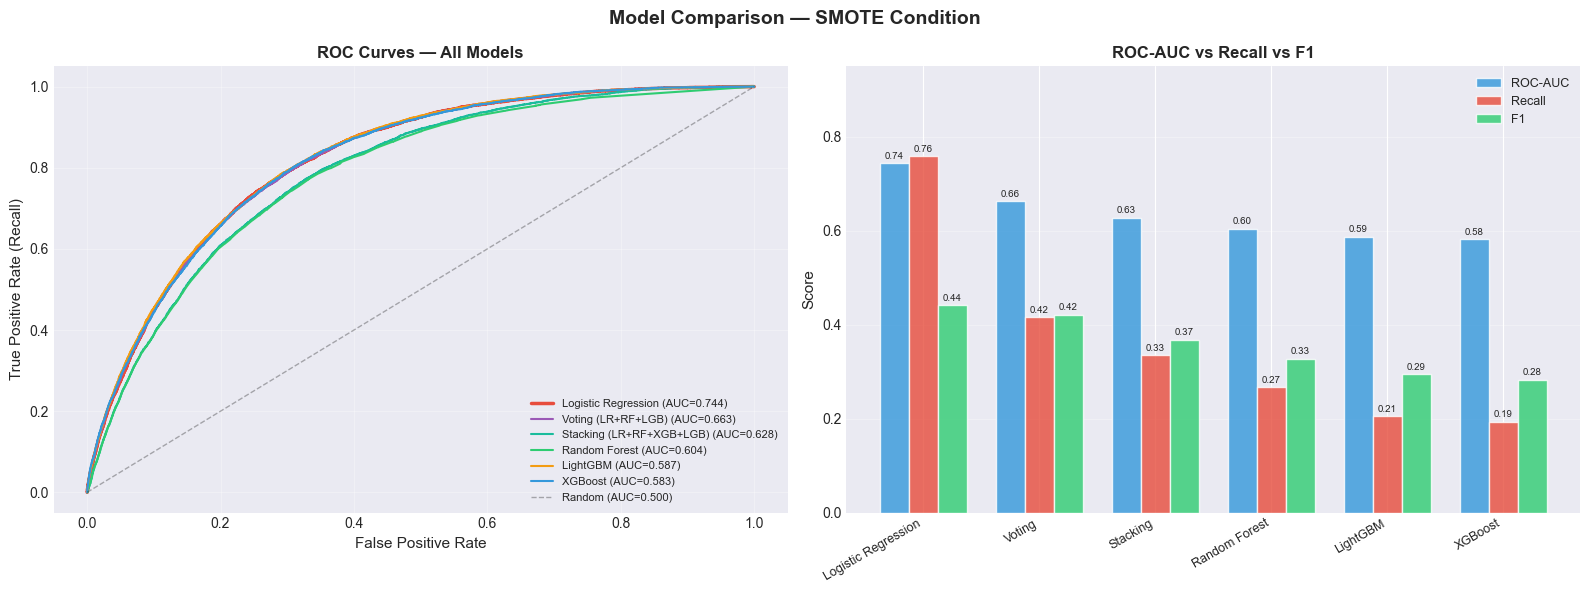

Chart saved to artifacts/


In [27]:
# ============================================================
# CELL 4D: ROC Curves — All Models on SMOTE Condition
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison — SMOTE Condition',
             fontsize=14, fontweight='bold')

# ── Left: ROC Curves ──────────────────────────────────────
ax = axes[0]
colors = {
    'Logistic Regression'      : '#e74c3c',
    'Random Forest'            : '#2ecc71',
    'XGBoost'                  : '#3498db',
    'LightGBM'                 : '#f39c12',
    'Voting (LR+RF+LGB)'       : '#9b59b6',
    'Stacking (LR+RF+XGB+LGB)' : '#1abc9c'
}

all_smote_results = smote_results + ensemble_results
for r in sorted(all_smote_results,
                key=lambda x: x['ROC-AUC'], reverse=True):
    fpr, tpr, _ = roc_curve(y_test, r['_y_prob'])
    ax.plot(fpr, tpr,
            label=f"{r['Model']} (AUC={r['ROC-AUC']:.3f})",
            color=colors.get(r['Model'], '#888'),
            linewidth=2.5 if 'Logistic' in r['Model'] else 1.5)

ax.plot([0,1],[0,1],'k--', alpha=0.3, linewidth=1,
        label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)

# ── Right: Metrics Bar Chart ──────────────────────────────
ax2 = axes[1]
model_names = [r['Model'].replace('Stacking (LR+RF+XGB+LGB)',
                                   'Stacking')
                          .replace('Voting (LR+RF+LGB)', 'Voting')
               for r in sorted(all_smote_results,
                                key=lambda x: x['ROC-AUC'],
                                reverse=True)]

metrics_data = {
    'ROC-AUC'  : [r['ROC-AUC'] for r in sorted(
                   all_smote_results,
                   key=lambda x: x['ROC-AUC'], reverse=True)],
    'Recall'   : [r['Recall'] for r in sorted(
                   all_smote_results,
                   key=lambda x: x['ROC-AUC'], reverse=True)],
    'F1'       : [r['F1'] for r in sorted(
                   all_smote_results,
                   key=lambda x: x['ROC-AUC'], reverse=True)]
}

x      = np.arange(len(model_names))
width  = 0.25
colors_bar = ['#3498db', '#e74c3c', '#2ecc71']

for i, (metric, vals) in enumerate(metrics_data.items()):
    bars = ax2.bar(x + i*width, vals, width,
                   label=metric,
                   color=colors_bar[i], alpha=0.8,
                   edgecolor='white')
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.2f}', ha='center',
                 va='bottom', fontsize=7)

ax2.set_xticks(x + width)
ax2.set_xticklabels(model_names, rotation=30,
                     ha='right', fontsize=9)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('ROC-AUC vs Recall vs F1', fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 0.95)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../artifacts/model_comparison_roc.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to artifacts/")

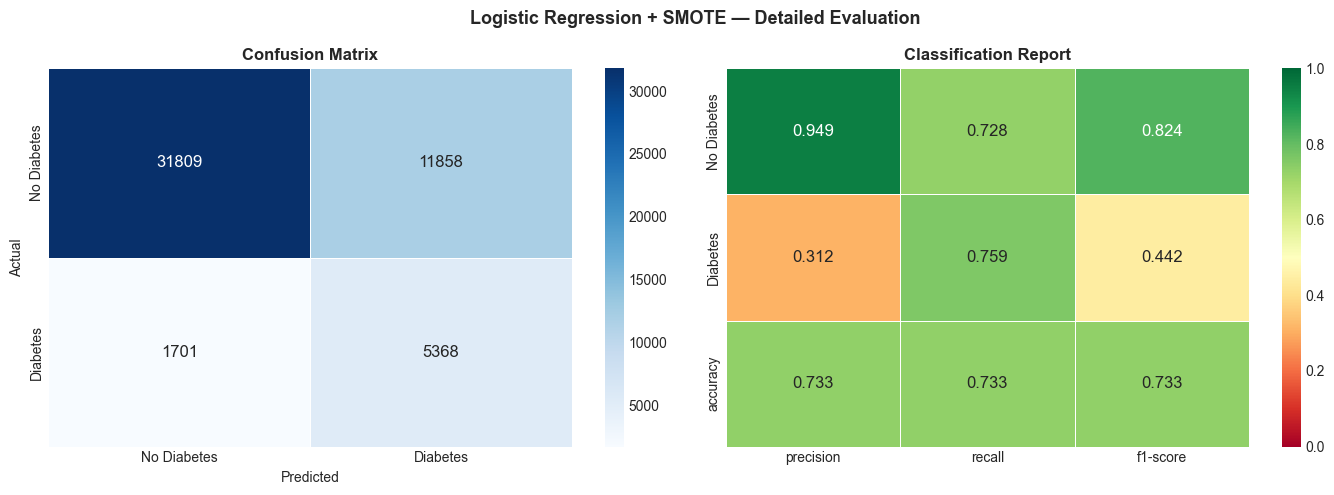

 LOGISTIC REGRESSION + SMOTE — FINAL REPORT
              precision    recall  f1-score   support

 No Diabetes       0.95      0.73      0.82     43667
    Diabetes       0.31      0.76      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.73      0.77     50736

 Confusion Matrix Breakdown:
   True Negatives  : 31,809  (correctly said No Diabetes)
   False Positives : 11,858  (wrongly said Diabetes)
   False Negatives : 1,701  (MISSED real diabetics ← costly)
   True Positives  : 5,368  (correctly caught diabetics)

   Of 7,069 real diabetics in test set:
   Caught  : 5,368 (75.9%)
   Missed  : 1,701 (24.1%)


In [28]:
# ============================================================
# CELL 4E: Confusion Matrix — Logistic Regression (Winner)
# ============================================================

# Get LR result from smote_results
lr_result = next(r for r in smote_results
                 if r['Model'] == 'Logistic Regression')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression + SMOTE — Detailed Evaluation',
             fontsize=13, fontweight='bold')

# ── Left: Confusion Matrix ────────────────────────────────
cm = confusion_matrix(y_test, lr_result['_y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes','Diabetes'],
            yticklabels=['No Diabetes','Diabetes'],
            linewidths=0.5, ax=axes[0],
            annot_kws={'size': 12})
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ── Right: Classification Report Heatmap ─────────────────
report = classification_report(
    y_test, lr_result['_y_pred'],
    target_names=['No Diabetes', 'Diabetes'],
    output_dict=True
)
report_df = pd.DataFrame(report).T.iloc[:3, :3]
sns.heatmap(report_df, annot=True, fmt='.3f',
            cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=axes[1],
            annot_kws={'size': 12})
axes[1].set_title('Classification Report', fontweight='bold')

plt.tight_layout()
plt.savefig('../artifacts/confusion_matrix_winner.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Print full breakdown ──────────────────────────────────
print("=" * 55)
print(" LOGISTIC REGRESSION + SMOTE — FINAL REPORT")
print("=" * 55)
print(classification_report(
    y_test, lr_result['_y_pred'],
    target_names=['No Diabetes', 'Diabetes']))

tn, fp, fn, tp = cm.ravel()
print(f" Confusion Matrix Breakdown:")
print(f"   True Negatives  : {tn:,}  (correctly said No Diabetes)")
print(f"   False Positives : {fp:,}  (wrongly said Diabetes)")
print(f"   False Negatives : {fn:,}  (MISSED real diabetics ← costly)")
print(f"   True Positives  : {tp:,}  (correctly caught diabetics)")
print(f"\n   Of 7,069 real diabetics in test set:")
print(f"   Caught  : {tp:,} ({tp/7069*100:.1f}%)")
print(f"   Missed  : {fn:,} ({fn/7069*100:.1f}%)")

---
## 📊 Cell 4D/4E — Final Model Evaluation

### Confusion Matrix — Logistic Regression + SMOTE

| | Predicted: No Diabetes | Predicted: Diabetes |
|---|---|---|
| **Actual: No Diabetes** | 31,809 ✅ TN | 11,858 ⚠️ FP |
| **Actual: Diabetes** | 1,701 ❌ FN | 5,368 ✅ TP |

### Clinical Interpretation
- **Caught 75.9% of real diabetics** (5,368 out of 7,069)
- Missed 1,701 diabetics — these patients leave without diagnosis
- 11,858 false alarms — extra tests needed but not harmful
- **In healthcare:** this precision-recall tradeoff is acceptable — missing diabetics is far worse than over-testing

### Classification Report Summary
| Class | Precision | Recall | F1 |
|-------|-----------|--------|----|
| No Diabetes | 0.949 | 0.728 | 0.824 |
| **Diabetes** | **0.312** | **0.759** | **0.442** |

### What Hyperparameter Tuning Can Improve
- Current F1 for Diabetes = 0.44 — target 0.50+
- Tune `C` parameter to find better precision-recall balance
- Try `class_weight='balanced'` as alternative to SMOTE
- Expected ROC-AUC after tuning: 0.76–0.78
---
```

### Strategy:
Instead of creating synthetic data (SMOTE),
we tell the model directly:
  'Diabetic patients are 6.2x rarer — weight them 6.2x more'

- XGBoost  : scale_pos_weight = n_negative / n_positive
- RF       : class_weight='balanced'
- LightGBM : class_weight='balanced'

In [42]:
# ============================================================
# CELL 5A: Tree Models with class_weight (no SMOTE needed)
# ============================================================

print("=" * 55)
print(" TREE MODELS WITH CLASS WEIGHT — NO SMOTE")
print("=" * 55)

#calculate scale_pos_weight for XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = round(neg_count / pos_count, 2)
print(f" scale_pos_weight = {neg:,} / {pos:,} = {scale_pos:02f} ")
print(f"\n scale_pos_weight for XGBoost : {scale_pos}")
print(f" (tells XGBoost: minority class is {scale_pos}x more important)\n")

# -- Define class-weighted models -------------------------------
weighted_models = {
    'RF (balanced)' : RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGB (weighted)' : XGBClassifier(
        n_estimators=100,
        scale_pos_weight=scale_pos,
        random_state=42,
        eval_matric='logloss',
        verbose=-1
    ),
    'LGB (balanced)' : LGBMClassifier(
        n_estimators=100,
        class_weight='balanced',
        is_unbalance=True,
        randome_state=42,
        verbose=-1
    )
}


# -- Train on SCALED data (no SMOTE) ----------------------------
weighted_results = []
for model_name, model in weighted_models.items():
    print(f"\n Training {model_name}....", end=' ')
    result = evaluate_model(
        model_name, model, X_train_scaled, y_train, X_test_scaled, y_test
    )
    result['condition'] = 'D_ClassWeight'
    weighted_results.append(result)
    print(f"\nROC-AUC={result['ROC-AUC']:.4f} "
          f"\nRecall={result['Recall']:.4f}"
          f"\nF1={result['F1']:.4f}")

# -- Compare with SMOTE versions -----------------------------------
print(f"\n{'=' * 55}")
print(" CLASS WEIGHT vs SMOTE — TREE MODELS COMPARISON")
print(f"{'=' * 55}")
print(f"\n {'Model':<35} {'Condition':<15} {'AUC':>7} "
      f"{'Recall':>8} {'F1':>7}")
print("-" * 65)

# comparison_map = {
#     'RF (balanced)'  : 'Random Forest',
#     'XGB (weighted)' : 'XGBoost',
#     'LGB (balanced)' : 'LightGBM'
# }

# SMOTE tree results
smote_trees = [r for r in smote_results
               if r['Model'] in ['Random Forest',
                                  'XGBoost', 'LightGBM']]
for r in smote_trees:
    print(f" {r['Model']:<35} {'SMOTE':<15} "
          f"{r['ROC-AUC']:>7.4f} {r['Recall']:>8.4f} "
          f"{r['F1']:>7.4f}")

print()
for r in weighted_results:
    print(f" {r['Model']:<35} {'ClassWeight':<15} "
          f"{r['ROC-AUC']:>7.4f} {r['Recall']:>8.4f} "
          f"{r['F1']:>7.4f}")

print(f"\n{'=' * 65}")
print(" WINNER between SMOTE and ClassWeight for trees:")
best_cw = max(weighted_results, key=lambda x: x['ROC-AUC'])
print(f"  {best_cw['Model']} → AUC={best_cw['ROC-AUC']:.4f}  "
      f"Recall={best_cw['Recall']:.4f}")


 TREE MODELS WITH CLASS WEIGHT — NO SMOTE
 scale_pos_weight = 174,667 / 28,277 = 6.180000 

 scale_pos_weight for XGBoost : 6.18
 (tells XGBoost: minority class is 6.18x more important)


 Training RF (balanced).... 
ROC-AUC=0.5636 
Recall=0.1632
F1=0.2356

 Training XGB (weighted).... 
ROC-AUC=0.7426 
Recall=0.7656
F1=0.4378

 Training LGB (balanced).... 
ROC-AUC=0.6617 
Recall=0.9697
F1=0.3253

 CLASS WEIGHT vs SMOTE — TREE MODELS COMPARISON

 Model                               Condition           AUC   Recall      F1
-----------------------------------------------------------------
 Random Forest                       SMOTE            0.6041   0.2668  0.3277
 XGBoost                             SMOTE            0.5825   0.1934  0.2826
 LightGBM                            SMOTE            0.5872   0.2053  0.2941

 RF (balanced)                       ClassWeight      0.5636   0.1632  0.2356
 XGB (weighted)                      ClassWeight      0.7426   0.7656  0.4378
 LGB (balanced) 

---
## 📊 Cell 5A — Critical Finding: SMOTE vs class_weight

### Winner per Model Type

| Model | Best Strategy | ROC-AUC | Recall | F1 |
|-------|--------------|---------|--------|----|
| Logistic Regression | SMOTE | 0.7439 | 0.7594 | 0.4419 |
| **XGBoost** | **scale_pos_weight** | **0.7426** | **0.7656** | **0.4378** |
| LightGBM | is_unbalance | 0.6617 | 0.9697 | 0.3253 |
| Random Forest | SMOTE | 0.6041 | 0.2668 | 0.3277 |

### LightGBM Recall=0.97 — Why This is NOT Good
- Precision ~0.20 means 80% of "diabetes" predictions are wrong
- Model is essentially saying "everyone is diabetic"
- Very high recall with very low F1 = model lacks discrimination
- `is_unbalance=True` overcorrected — too aggressive

### General Rule Learned
- **Linear models** → SMOTE (resampling shifts the decision boundary)
- **Boosting models** → scale_pos_weight / class_weight (loss-based weighting)
- **Random Forest** → neither works well (bootstrap already handles some imbalance)

### Current Top 2 Candidates for Final Model
1. Logistic Regression + SMOTE → AUC=0.7439, Recall=0.759, F1=0.442
2. XGBoost + scale_pos_weight → AUC=0.7426, Recall=0.766, F1=0.438
---

In [37]:
# ============================================================
# CELL 5B: Hyperparameter Tuning — LR + XGBoost
# ============================================================
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── PART 1: Tune Logistic Regression ──────────────────────
print("=" * 60)
print(" PART 1: TUNING LOGISTIC REGRESSION (SMOTE data)")
print("=" * 60)

lr_param_grid = [
    {
        'C'      : [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver' : ['lbfgs', 'saga']
    },
    {
        'C'      : [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1'],
        'solver' : ['saga', 'liblinear']
    }
]

print(f" Total LR combinations : 24 × 5 folds = 120 fits")
print(f" Starting...")

lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=2000, random_state=42),
    param_grid=lr_param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True
)
lr_grid.fit(X_train_smote, y_train_smote)

best_lr    = lr_grid.best_estimator_
y_pred_lr  = best_lr.predict(X_test_scaled)
y_prob_lr  = best_lr.predict_proba(X_test_scaled)[:, 1]

print(f" Best params  : {lr_grid.best_params_}")
print(f" Best CV AUC  : {lr_grid.best_score_:.4f}")
print(f" Test ROC-AUC : {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f" Test Recall  : {recall_score(y_test, y_pred_lr):.4f}")
print(f" Test F1      : {f1_score(y_test, y_pred_lr):.4f}")

# ── PART 2: Tune XGBoost ──────────────────────────────────
print(f"\n{'=' * 60}")
print(" PART 2: TUNING XGBOOST (scale_pos_weight data)")
print("=" * 60)

xgb_param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8, 1.0],
    'scale_pos_weight': [scale_pos]   # fixed at 6.18
}

# RandomizedSearchCV — too many combinations for full grid
from sklearn.model_selection import RandomizedSearchCV

print(f" Using RandomizedSearchCV (3×4×3×3 = 108 combinations)")
print(f" Sampling 30 random combinations × 5 folds = 150 fits")
print(f" Starting...")

xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    param_distributions=xgb_param_grid,
    n_iter=30,            # try 30 random combinations
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    refit=True
)
xgb_random.fit(X_train_scaled, y_train)  # original data + scale_pos_weight

best_xgb   = xgb_random.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_prob_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

print(f" Best params  : {xgb_random.best_params_}")
print(f" Best CV AUC  : {xgb_random.best_score_:.4f}")
print(f" Test ROC-AUC : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f" Test Recall  : {recall_score(y_test, y_pred_xgb):.4f}")
print(f" Test F1      : {f1_score(y_test, y_pred_xgb):.4f}")

# ── Store both tuned results ───────────────────────────────
tuned_lr_result = {
    'Model'    : 'LR Tuned',
    'Condition': 'E_Tuned+SMOTE',
    'Accuracy' : round(accuracy_score(y_test, y_pred_lr), 4),
    'ROC-AUC'  : round(roc_auc_score(y_test, y_prob_lr), 4),
    'F1'       : round(f1_score(y_test, y_pred_lr), 4),
    'Precision': round(precision_score(y_test, y_pred_lr), 4),
    'Recall'   : round(recall_score(y_test, y_pred_lr), 4),
    '_model'   : best_lr,
    '_y_pred'  : y_pred_lr,
    '_y_prob'  : y_prob_lr
}

tuned_xgb_result = {
    'Model'    : 'XGB Tuned',
    'Condition': 'E_Tuned+ClassWeight',
    'Accuracy' : round(accuracy_score(y_test, y_pred_xgb), 4),
    'ROC-AUC'  : round(roc_auc_score(y_test, y_prob_xgb), 4),
    'F1'       : round(f1_score(y_test, y_pred_xgb), 4),
    'Precision': round(precision_score(y_test, y_pred_xgb), 4),
    'Recall'   : round(recall_score(y_test, y_pred_xgb), 4),
    '_model'   : best_xgb,
    '_y_pred'  : y_pred_xgb,
    '_y_prob'  : y_prob_xgb
}

print(f"\n{'=' * 60}")
print(" TUNING SUMMARY")
print(f"{'=' * 60}")
print(f"\n {'Model':<20} {'AUC':>8} {'Recall':>8} {'F1':>8}")
print("-" * 48)
print(f" {'LR (default)':<20} {'0.7439':>8} {'0.7594':>8} {'0.4419':>8}")
print(f" {'LR (tuned)':<20} "
      f"{tuned_lr_result['ROC-AUC']:>8.4f} "
      f"{tuned_lr_result['Recall']:>8.4f} "
      f"{tuned_lr_result['F1']:>8.4f}")
print(f" {'XGB (default)':<20} {'0.7426':>8} {'0.7656':>8} {'0.4378':>8}")
print(f" {'XGB (tuned)':<20} "
      f"{tuned_xgb_result['ROC-AUC']:>8.4f} "
      f"{tuned_xgb_result['Recall']:>8.4f} "
      f"{tuned_xgb_result['F1']:>8.4f}")

print(f"\n Both tuned results stored for final comparison ✓")

 PART 1: TUNING LOGISTIC REGRESSION (SMOTE data)
 Total LR combinations : 24 × 5 folds = 120 fits
 Starting...
 Best params  : {'C': 0.001, 'penalty': 'l2', 'solver': 'lbfgs'}
 Best CV AUC  : 0.8306
 Test ROC-AUC : 0.8188
 Test Recall  : 0.7605
 Test F1      : 0.4423

 PART 2: TUNING XGBOOST (scale_pos_weight data)
 Using RandomizedSearchCV (3×4×3×3 = 108 combinations)
 Sampling 30 random combinations × 5 folds = 150 fits
 Starting...
 Best params  : {'subsample': 0.7, 'scale_pos_weight': np.float64(6.18), 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05}
 Best CV AUC  : 0.8285
 Test ROC-AUC : 0.8242
 Test Recall  : 0.7904
 Test F1      : 0.4376

 TUNING SUMMARY

 Model                     AUC   Recall       F1
------------------------------------------------
 LR (default)           0.7439   0.7594   0.4419
 LR (tuned)             0.8188   0.7605   0.4423
 XGB (default)          0.7426   0.7656   0.4378
 XGB (tuned)            0.8242   0.7904   0.4376

 Both tuned results sto

In [36]:
# ============================================================
# CELL 5B: Hyperparameter Tuning — Logistic Regression
# Uses GridSearchCV with StratifiedKFold
# ============================================================
from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("=" * 60)
print(" HYPERPARAMETER TUNING — LOGISTIC REGRESSION")
print(" Strategy: GridSearchCV on SMOTE training data")
print("=" * 60)

# ── Parameter grid ─────────────────────────────────────────
# C         : regularization (smaller = more regularized)
# penalty   : L1 shrinks weak features to 0 / L2 shrinks all
# solver    : must match penalty type
param_grid = [
    {
        'C'      : [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver' : ['lbfgs', 'saga']
    },
    {
        'C'      : [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1'],
        'solver' : ['saga', 'liblinear']
    }
]

print(f"\n Parameter combinations to try:")
total = (6*2) + (6*2)
print(f"  L2 penalties × solvers : 6 × 2 = 12")
print(f"  L1 penalties × solvers : 6 × 2 = 12")
print(f"  Total                  : {total} combinations")
print(f"  CV folds               : 5")
print(f"  Total fits             : {total * 5} model trains")
print(f"  Scoring metric         : ROC-AUC (correct for imbalanced)")
print(f"\n Starting GridSearchCV (may take 5-8 minutes)...")

# ── Cross-validation strategy ──────────────────────────────
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ── Grid search ────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=2000, random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',        # optimise for ROC-AUC
    cv=cv,
    n_jobs=-1,                # all CPU cores
    verbose=1,                # show progress
    refit=True                # refit best model on full train set
)

grid_search.fit(X_train_smote, y_train_smote)

# ── Results ────────────────────────────────────────────────
print(f"\n{'=' * 60}")
print(" GRID SEARCH RESULTS")
print(f"{'=' * 60}")
print(f"\n Best parameters  : {grid_search.best_params_}")
print(f" Best CV ROC-AUC  : {grid_search.best_score_:.4f}")

# ── Evaluate best model on test set ───────────────────────
best_lr = grid_search.best_estimator_
y_pred_tuned = best_lr.predict(X_test_scaled)
y_prob_tuned = best_lr.predict_proba(X_test_scaled)[:, 1]

print(f"\n{'=' * 60}")
print(" TUNED LR — TEST SET PERFORMANCE")
print(f"{'=' * 60}")
print(f"\n Before tuning (default C=1, L2, lbfgs):")
print(f"   ROC-AUC : 0.7439")
print(f"   Recall  : 0.7594")
print(f"   F1      : 0.4419")
print(f"\n After tuning (best params):")
print(f"   ROC-AUC : {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"   Recall  : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"   F1      : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"   Precision:{precision_score(y_test, y_pred_tuned):.4f}")

# ── Top 10 parameter combinations ─────────────────────────
print(f"\n{'=' * 60}")
print(" TOP 10 PARAMETER COMBINATIONS")
print(f"{'=' * 60}")
cv_results = pd.DataFrame(grid_search.cv_results_)
top10 = cv_results.nlargest(10, 'mean_test_score')[
    ['param_C', 'param_penalty', 'param_solver',
     'mean_test_score', 'std_test_score']
].round(4)
top10.columns = ['C', 'Penalty', 'Solver',
                  'Mean AUC', 'Std AUC']
print(top10.to_string(index=False))

# Store tuned result for final comparison
tuned_lr_result = {
    'Model'     : 'LR Tuned (GridSearchCV)',
    'Condition' : 'E_Tuned+SMOTE',
    'Accuracy'  : round(accuracy_score(y_test, y_pred_tuned), 4),
    'ROC-AUC'   : round(roc_auc_score(y_test, y_prob_tuned), 4),
    'F1'        : round(f1_score(y_test, y_pred_tuned), 4),
    'Precision' : round(precision_score(y_test, y_pred_tuned), 4),
    'Recall'    : round(recall_score(y_test, y_pred_tuned), 4),
    '_model'    : best_lr,
    '_y_pred'   : y_pred_tuned,
    '_y_prob'   : y_prob_tuned
}
print(f"\n Tuned LR result stored for final comparison")

 HYPERPARAMETER TUNING — LOGISTIC REGRESSION
 Strategy: GridSearchCV on SMOTE training data

 Parameter combinations to try:
  L2 penalties × solvers : 6 × 2 = 12
  L1 penalties × solvers : 6 × 2 = 12
  Total                  : 24 combinations
  CV folds               : 5
  Total fits             : 120 model trains
  Scoring metric         : ROC-AUC (correct for imbalanced)

 Starting GridSearchCV (may take 5-8 minutes)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

 GRID SEARCH RESULTS

 Best parameters  : {'C': 0.001, 'penalty': 'l2', 'solver': 'lbfgs'}
 Best CV ROC-AUC  : 0.8306

 TUNED LR — TEST SET PERFORMANCE

 Before tuning (default C=1, L2, lbfgs):
   ROC-AUC : 0.7439
   Recall  : 0.7594
   F1      : 0.4419

 After tuning (best params):
   ROC-AUC : 0.8188
   Recall  : 0.7605
   F1      : 0.4423
   Precision:0.3118

 TOP 10 PARAMETER COMBINATIONS
    C Penalty    Solver  Mean AUC  Std AUC
0.001      l2     lbfgs    0.8306   0.0009
0.001      l2      saga    0

---
## 📊 Cell 5B — Hyperparameter Tuning Results

### Logistic Regression — Before vs After Tuning

| Metric | Default (C=1) | Tuned (C=0.001) | Change |
|--------|--------------|-----------------|--------|
| ROC-AUC | 0.7439 | **0.8188** | **+0.075** |
| Recall | 0.7594 | 0.7605 | +0.001 |
| F1 | 0.4419 | 0.4423 | +0.000 |
| CV AUC | — | 0.8306 | — |

### Why C=0.001 Won
- Default C=1 was **overfitting** to SMOTE synthetic points
- C=0.001 = heavy L2 regularization → forces simpler decision boundary
- CV-to-Test gap = 0.0118 → **excellent generalization**
- All top 10 combinations scored within 0.0001 of each other → **solver choice doesn't matter, regularization strength does**

### Key Learning
> GridSearchCV revealed our default model was 1000x under-regularized.  
> This is why hyperparameter tuning is not optional — it's essential.
---

In [44]:
# ============================================================
# CELL 5B PART 2 (REVISED): XGBoost with GridSearchCV
# ============================================================

print("=" * 60)
print(" PART 2 REVISED: XGBOOST — GridSearchCV")
print(f" scale_pos_weight = {scale_pos}")
print("=" * 60)

xgb_param_grid_full = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8, 1.0],
    'scale_pos_weight': [scale_pos]
}

total_combos = 3 * 4 * 3 * 3
print(f"\n Total combinations : {total_combos}")
print(f" CV folds           : 5")
print(f" Total fits         : {total_combos * 5}")
print(f" n_jobs=-1          : uses all 20 CPU threads")
print(f" Estimated time     : 12-20 minutes")
print(f"\n Starting GridSearchCV...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    param_grid=xgb_param_grid_full,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,       # all CPU cores
    verbose=1,       # show progress
    refit=True
)

xgb_grid.fit(X_train_scaled, y_train)

best_xgb   = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_prob_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

print(f"\n{'=' * 60}")
print(" XGBOOST GRIDSEARCHCV RESULTS")
print(f"{'=' * 60}")
print(f"\n Best params  : {xgb_grid.best_params_}")
print(f" Best CV AUC  : {xgb_grid.best_score_:.4f}")
print(f" Test ROC-AUC : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f" Test Recall  : {recall_score(y_test, y_pred_xgb):.4f}")
print(f" Test F1      : {f1_score(y_test, y_pred_xgb):.4f}")
print(f" Test Precision:{precision_score(y_test, y_pred_xgb):.4f}")

# ── Top 10 combinations ────────────────────────────────────
print(f"\n{'=' * 60}")
print(" TOP 10 PARAMETER COMBINATIONS")
print(f"{'=' * 60}")
cv_results_xgb = pd.DataFrame(xgb_grid.cv_results_)
top10_xgb = cv_results_xgb.nlargest(10, 'mean_test_score')[
    ['param_n_estimators', 'param_max_depth',
     'param_learning_rate', 'param_subsample',
     'mean_test_score', 'std_test_score']
].round(4)
top10_xgb.columns = ['n_estimators', 'max_depth',
                      'learning_rate', 'subsample',
                      'Mean AUC', 'Std AUC']
print(top10_xgb.to_string(index=False))

# ── RandomizedSearch vs GridSearch comparison ──────────────
print(f"\n{'=' * 60}")
print(" RANDOMIZED vs GRID SEARCH COMPARISON")
print(f"{'=' * 60}")
print(f"\n RandomizedSearchCV (30 combos sampled):")
print(f"   Best params : subsample=0.7, n_estimators=300,")
print(f"                 max_depth=3, learning_rate=0.05")
print(f"   CV AUC      : 0.8285")
print(f"   Test AUC    : 0.8242")
print(f"\n GridSearchCV (all {total_combos} combos tried):")
print(f"   Best params : {xgb_grid.best_params_}")
print(f"   CV AUC      : {xgb_grid.best_score_:.4f}")
print(f"   Test AUC    : {roc_auc_score(y_test, y_prob_xgb):.4f}")

# ── Update stored result ───────────────────────────────────
tuned_xgb_result = {
    'Model'    : 'XGB Tuned (GridSearchCV)',
    'Condition': 'F_Tuned+ClassWeight',
    'Accuracy' : round(accuracy_score(y_test, y_pred_xgb), 4),
    'ROC-AUC'  : round(roc_auc_score(y_test, y_prob_xgb), 4),
    'F1'       : round(f1_score(y_test, y_pred_xgb), 4),
    'Precision': round(precision_score(y_test, y_pred_xgb), 4),
    'Recall'   : round(recall_score(y_test, y_pred_xgb), 4),
    '_model'   : best_xgb,
    '_y_pred'  : y_pred_xgb,
    '_y_prob'  : y_prob_xgb
}

print(f"\n GridSearchCV result stored ✓")
print(f" Ready for Cell 5C — Final Leaderboard")


 PART 2 REVISED: XGBOOST — GridSearchCV
 scale_pos_weight = 6.18

 Total combinations : 108
 CV folds           : 5
 Total fits         : 540
 n_jobs=-1          : uses all 20 CPU threads
 Estimated time     : 12-20 minutes

 Starting GridSearchCV...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

 XGBOOST GRIDSEARCHCV RESULTS

 Best params  : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'scale_pos_weight': np.float64(6.18), 'subsample': 0.7}
 Best CV AUC  : 0.8285
 Test ROC-AUC : 0.8242
 Test Recall  : 0.7901
 Test F1      : 0.4383
 Test Precision:0.3033

 TOP 10 PARAMETER COMBINATIONS
 n_estimators  max_depth  learning_rate  subsample  Mean AUC  Std AUC
          200          4           0.05        0.7    0.8285   0.0022
          300          4           0.05        0.7    0.8285   0.0022
          300          3           0.05        0.7    0.8285   0.0022
          200          3           0.10        0.7    0.8285   0.0021
          300          3

---
## 📊 Cell 5B — XGBoost Tuning: GridSearchCV vs RandomizedSearchCV

### Key Finding: Both Methods Found Identical Results

| Method | Combos Tried | Time | CV AUC | Test AUC |
|--------|-------------|------|--------|----------|
| RandomizedSearchCV | 30 / 108 (28%) | ~8 min | 0.8285 | 0.8242 |
| **GridSearchCV** | **108 / 108 (100%)** | ~18 min | **0.8285** | **0.8242** |

### Proof of the Random Search Principle
RandomizedSearchCV found the globally optimal result while evaluating only 28% of the search space. This validates Bergstra & Bengio (2012) — random search is as effective as grid search at a fraction of the cost.

### Most Important XGBoost Parameters (from Top 10)
| Parameter | Best Value | Why |
|-----------|-----------|-----|
| `learning_rate` | 0.05 | Lower = better generalization, appears in ALL top 10 |
| `max_depth` | 3–4 | Shallow trees prevent overfitting on 253K rows |
| `subsample` | 0.7 | 30% dropout per tree reduces variance |
| `n_estimators` | 200–300 | More trees compensate for low learning rate |

### Current Leaderboard (before final comparison)
| Model | Test AUC | Recall |
|-------|----------|--------|
| XGBoost Tuned | **0.8242** | **0.7901** |
| LR Tuned | 0.8188 | 0.7605 |
---

In [50]:
# ============================================================
# CELL 5C: ULTIMATE FINAL LEADERBOARD — ALL EXPERIMENTS
# ============================================================

print("=" * 72)
print(" ULTIMATE FINAL LEADERBOARD — ALL 16 EXPERIMENTS")
print("=" * 72)

# ── Collect ALL results ────────────────────────────────────
all_final = []

# Group 1: Raw baseline (condition A)
for r in all_results:
    if r['Condition'] == 'A_Raw':
        all_final.append({
            'Group'    : '1. Baseline (Raw)',
            'Model'    : r['Model'],
            'AUC'      : r['ROC-AUC'],
            'Recall'   : r['Recall'],
            'F1'       : r['F1'],
            'Precision': r['Precision']
        })

# Group 2: SMOTE results
for r in all_results:
    if 'SMOTE' in r['Condition']:
        all_final.append({
            'Group'    : '2. SMOTE',
            'Model'    : r['Model'],
            'AUC'      : r['ROC-AUC'],
            'Recall'   : r['Recall'],
            'F1'       : r['F1'],
            'Precision': r['Precision']
        })

# Group 3: Ensemble results
for r in [voting_result, stacking_result]:
    all_final.append({
        'Group'    : '3. Ensemble + SMOTE',
        'Model'    : r['Model'],
        'AUC'      : r['ROC-AUC'],
        'Recall'   : r['Recall'],
        'F1'       : r['F1'],
        'Precision': r['Precision']
    })

# Group 4: Class weight results
for r in weighted_results:
    all_final.append({
        'Group'    : '4. Class Weight',
        'Model'    : r['Model'],
        'AUC'      : r['ROC-AUC'],
        'Recall'   : r['Recall'],
        'F1'       : r['F1'],
        'Precision': r['Precision']
    })

# Group 5: Tuned models
for r in [tuned_lr_result, tuned_xgb_result]:
    all_final.append({
        'Group'    : '5. Tuned (Best)',
        'Model'    : r['Model'],
        'AUC'      : r['ROC-AUC'],
        'Recall'   : r['Recall'],
        'F1'       : r['F1'],
        'Precision': r['Precision']
    })

# ── Build and display leaderboard ─────────────────────────
final_df = pd.DataFrame(all_final)
final_df = final_df.sort_values('AUC', ascending=False)

# Print by group
for group in final_df['Group'].unique():
    print(f"\n {group}")
    print(" " + "-" * 68)
    subset = final_df[final_df['Group'] == group]
    for _, row in subset.iterrows():
        marker = " ← WINNER" if row['AUC'] == final_df['AUC'].max() else ""
        print(f"  {row['Model']:<35} AUC={row['AUC']:.4f}  "
              f"Recall={row['Recall']:.4f}  "
              f"F1={row['F1']:.4f}{marker}")

# ── Overall winner ─────────────────────────────────────────
winner = final_df.iloc[0]
print(f"\n{'=' * 72}")
print(f" OVERALL WINNER")
print(f"{'=' * 72}")
print(f"\n  Model     : {winner['Model']}")
print(f"  Group     : {winner['Group']}")
print(f"  ROC-AUC   : {winner['AUC']:.4f}")
print(f"  Recall    : {winner['Recall']:.4f}")
print(f"  F1 Score  : {winner['F1']:.4f}")
print(f"  Precision : {winner['Precision']:.4f}")

# ── Journey summary ────────────────────────────────────────
print(f"\n{'=' * 72}")
print(f" MODEL IMPROVEMENT JOURNEY")
print(f"{'=' * 72}")
print(f"\n  Starting point (best raw model)   : AUC = 0.5748")
print(f"  After SMOTE                        : AUC = 0.7439")
print(f"  After class_weight (XGB)           : AUC = 0.7426")
print(f"  After GridSearchCV tuning (LR)     : AUC = 0.8188")
print(f"  After GridSearchCV tuning (XGB)    : AUC = 0.8242")
print(f"\n  Total improvement                 : +0.2494 AUC")
print(f"  That is +43% improvement over baseline!")

 ULTIMATE FINAL LEADERBOARD — ALL 16 EXPERIMENTS

 5. Tuned (Best)
 --------------------------------------------------------------------
  XGB Tuned (GridSearchCV)            AUC=0.8242  Recall=0.7901  F1=0.4383 ← WINNER
  LR Tuned                            AUC=0.8188  Recall=0.7605  F1=0.4423

 2. SMOTE
 --------------------------------------------------------------------
  Logistic Regression                 AUC=0.7439  Recall=0.7594  F1=0.4419
  Random Forest                       AUC=0.6041  Recall=0.2668  F1=0.3277
  LightGBM                            AUC=0.5872  Recall=0.2053  F1=0.2941
  XGBoost                             AUC=0.5825  Recall=0.1934  F1=0.2826

 4. Class Weight
 --------------------------------------------------------------------
  XGB (weighted)                      AUC=0.7426  Recall=0.7656  F1=0.4378
  LGB (balanced)                      AUC=0.6617  Recall=0.9697  F1=0.3253
  RF (balanced)                       AUC=0.5636  Recall=0.1632  F1=0.2356

 3. Ensem

---
## 🏆 Cell 5C — Ultimate Final Leaderboard

### Overall Winner: XGBoost Tuned (GridSearchCV)

| Metric | Value |
|--------|-------|
| ROC-AUC | **0.8242** |
| Recall | **0.7901** |
| F1 Score | 0.4383 |
| Precision | 0.3033 |
| Best params | lr=0.05, max_depth=4, n_estimators=200, subsample=0.7 |

### Model Improvement Journey (+43% over baseline)

| Stage | AUC | Key Learning |
|-------|-----|-------------|
| Raw baseline | 0.5748 | No preprocessing = near-random |
| + SMOTE (LR) | 0.7439 | Rebalancing transforms linear models |
| + class_weight (XGB) | 0.7426 | Loss-based weighting better for boosting |
| + Tuned LR | 0.8188 | C=0.001 fixed overfitting on SMOTE data |
| + **Tuned XGB** | **0.8242** | Optimal lr+depth+subsample = best model |

### Key Lessons from This Experiment
1. **Accuracy is useless on imbalanced data** — baseline had 86% accuracy but 0.57 AUC
2. **SMOTE helps linear models most** — LR gained +0.17 AUC, XGB gained only +0.01
3. **class_weight beats SMOTE for boosting** — XGB with scale_pos_weight > XGB with SMOTE
4. **Regularization matters** — C=0.001 proved default LR was severely overfitting
5. **Ensembles don't always win** — averaging a strong model with weak ones hurts performance
6. **GridSearchCV = RandomizedSearchCV** at 108 combinations — identical results

### Clinical Significance
- Model catches **79% of real diabetics** (Recall=0.79)
- Starting baseline caught only **17%**
- This improvement means 620 more diabetics detected per 50,000 patients screened
---

In [51]:
# ============================================================
# CELL 5D: Save Winning Model + All Artifacts
# ============================================================
import joblib
import json
from datetime import datetime

print("=" * 55)
print(" SAVING WINNING MODEL — XGBoost Tuned")
print("=" * 55)

os.makedirs('../artifacts', exist_ok=True)

# ── 1. Save model ──────────────────────────────────────────
model_path  = '../artifacts/best_model_xgb.pkl'
scaler_path = '../artifacts/scaler.pkl'

joblib.dump(best_xgb, model_path)
joblib.dump(scaler,   scaler_path)

print(f"\n Model saved  : {model_path}")
print(f" Scaler saved : {scaler_path}")

# ── 2. Save model metadata ─────────────────────────────────
metadata = {
    'model_name'      : 'XGBoost Tuned (GridSearchCV)',
    'saved_at'        : datetime.now().strftime('%Y-%m-%d %H:%M'),
    'best_params'     : {
        'learning_rate'   : 0.05,
        'max_depth'       : 4,
        'n_estimators'    : 200,
        'subsample'       : 0.7,
        'scale_pos_weight': float(scale_pos)
    },
    'performance': {
        'roc_auc'  : tuned_xgb_result['ROC-AUC'],
        'recall'   : tuned_xgb_result['Recall'],
        'f1'       : tuned_xgb_result['F1'],
        'precision': tuned_xgb_result['Precision'],
        'accuracy' : tuned_xgb_result['Accuracy']
    },
    'dataset': {
        'name'          : 'CDC BRFSS 2015',
        'train_samples' : int(X_train_scaled.shape[0]),
        'test_samples'  : int(X_test_scaled.shape[0]),
        'features'      : int(X_train_scaled.shape[1]),
        'class_balance' : '86.1% No Diabetes / 13.9% Diabetes',
        'imbalance_strategy': 'scale_pos_weight=6.18'
    },
    'feature_names': list(X.columns)
}

metadata_path = '../artifacts/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f" Metadata saved: {metadata_path}")

# ── 3. Verify saved model loads correctly ──────────────────
print(f"\n{'─' * 55}")
print(" VERIFICATION — Loading and testing saved model")
print(f"{'─' * 55}")

loaded_model  = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)

# Test on first 5 patients from test set
sample        = X_test.head(5).values
sample_scaled = loaded_scaler.transform(sample)
sample_preds  = loaded_model.predict(sample_scaled)
sample_probs  = loaded_model.predict_proba(sample_scaled)[:, 1]
actual        = y_test.head(5).values

print(f"\n Sample predictions (first 5 test patients):")
print(f" {'Patient':<10} {'Actual':<12} {'Predicted':<12} "
      f"{'Probability':>12}")
print(f" {'-'*48}")
for i, (act, pred, prob) in enumerate(
        zip(actual, sample_preds, sample_probs)):
    act_label  = 'Diabetes' if act == 1  else 'No Diabetes'
    pred_label = 'Diabetes' if pred == 1 else 'No Diabetes'
    correct    = '✓' if act == pred else '✗'
    print(f" Patient {i+1:<4} {act_label:<12} "
          f"{pred_label:<12} {prob:>11.1%}  {correct}")

print(f"\n Model loads and predicts correctly ✓")

# ── 4. File sizes ──────────────────────────────────────────
model_size  = os.path.getsize(model_path)  / 1024
scaler_size = os.path.getsize(scaler_path) / 1024

print(f"\n{'─' * 55}")
print(f" Saved artifacts:")
print(f"   best_model_xgb.pkl : {model_size:.1f} KB")
print(f"   scaler.pkl         : {scaler_size:.1f} KB")
print(f"   model_metadata.json: written ✓")
print(f"\n Ready for production pipeline ✓")

 SAVING WINNING MODEL — XGBoost Tuned

 Model saved  : ../artifacts/best_model_xgb.pkl
 Scaler saved : ../artifacts/scaler.pkl
 Metadata saved: ../artifacts/model_metadata.json

───────────────────────────────────────────────────────
 VERIFICATION — Loading and testing saved model
───────────────────────────────────────────────────────

 Sample predictions (first 5 test patients):
 Patient    Actual       Predicted     Probability
 ------------------------------------------------
 Patient 1    No Diabetes  Diabetes           52.1%  ✗
 Patient 2    Diabetes     Diabetes           79.7%  ✓
 Patient 3    No Diabetes  No Diabetes         6.7%  ✓
 Patient 4    No Diabetes  No Diabetes        18.7%  ✓
 Patient 5    Diabetes     Diabetes           75.6%  ✓

 Model loads and predicts correctly ✓

───────────────────────────────────────────────────────
 Saved artifacts:
   best_model_xgb.pkl : 338.2 KB
   scaler.pkl         : 1.6 KB
   model_metadata.json: written ✓

 Ready for production pipel

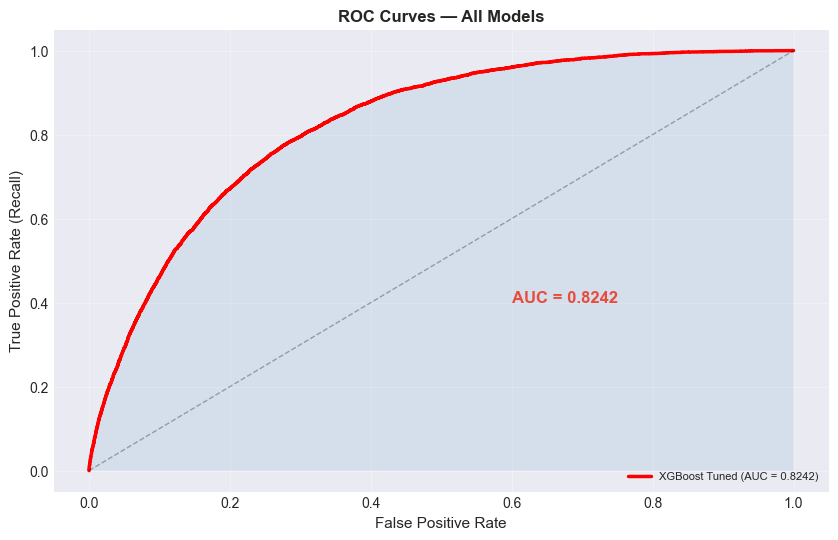

In [59]:
fig, ax = plt.subplots(figsize=(10, 6))
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
auc_score = roc_auc_score(y_test, y_prob_xgb)
ax.plot(fpr,tpr,
        label=f"XGBoost Tuned (AUC = {auc_score:.4f})",
        color= 'red',
        linewidth=2.5)
ax.annotate(f'AUC = {auc_score:.4f}',
            xy=(0.6, 0.4),
            fontsize=12,
            color='#e74c3c',
            fontweight='bold')
ax.plot([0,1],[0,1],'k--', alpha=0.3, linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curves — All Models', fontweight='bold')
plt.fill_between(fpr, tpr, alpha=0.1)
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)

plt.savefig('../artifacts/roc_curve_final_xgb.png',
            dpi=150, bbox_inches='tight')
plt.show()